# 4장 시각화 라이브러리I

## 4.1 데이터 시각화 이해

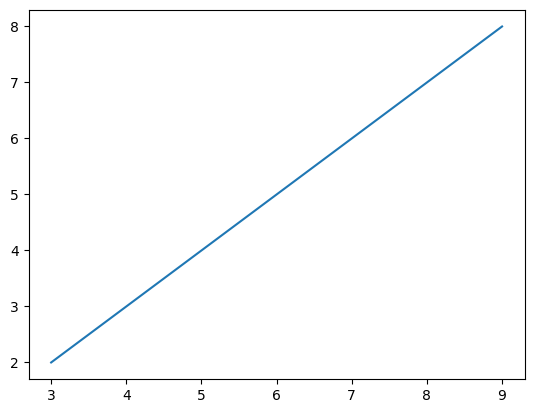

In [1]:
import matplotlib.pyplot as plt	#1단계
xdata = [3, 5, 7, 9]			#2단계
ydata = [2, 4, 6, 8]
plt.plot(xdata, ydata)			#3단계
plt.show()						#4단계

## 4.2 맷플롯립(Matplotlib) 라이브러리

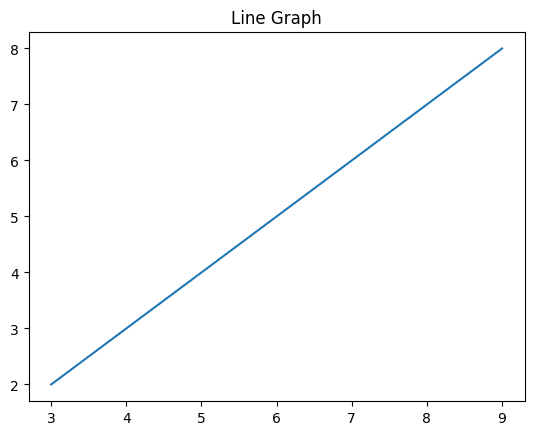

In [2]:
import matplotlib.pyplot as plt
plt.title('Line Graph')
xdata = [3, 5, 7, 9]
ydata = [2, 4, 6, 8]
plt.plot(xdata, ydata)
plt.show()

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel('/content/drive/MyDrive/MyLecture/2026/데이터시각화/04_data1.xlsx', index_col='area')
data.head()

,2015_good,2016_good,2017_good,2018_good,2019_good,2020_good,2015_common,2016_common,2017_common,2018_common,...,2017_bad,2018_bad,2019_bad,2020_bad,2015_verybad,2016_verybad,2017_verybad,2018_verybad,2019_verybad,2020_verybad
area,,,,,,,,,,,,,,,,,,,,,
Nationwide,72.0,54,84,135,117,171,267.0,297,265,209,...,14,21,16,0,1.0,2,2,0,1,0
Metropolitan,72.0,45,77,126,109,150,259.0,290,260,217,...,26,22,27,4,4.0,2,2,0,3,0
Seoul,97.0,65,113,140,139,168,243.0,277,230,204,...,20,21,25,5,4.0,1,2,0,3,0
Busan,102.0,89,86,136,163,208,242.0,259,269,212,...,10,16,9,2,1.0,2,0,1,0,0
Daegu,90.0,103,111,155,148,176,248.0,246,244,196,...,10,13,17,4,1.0,1,0,1,0,0


In [5]:
data2020_good = data['2020_good']
data2020_good

,2020_good
area,
Nationwide,171
Metropolitan,150
Seoul,168
Busan,208
Daegu,176
Incheon,182
Gwangju,210
Daejeon,182
Ulsan,206


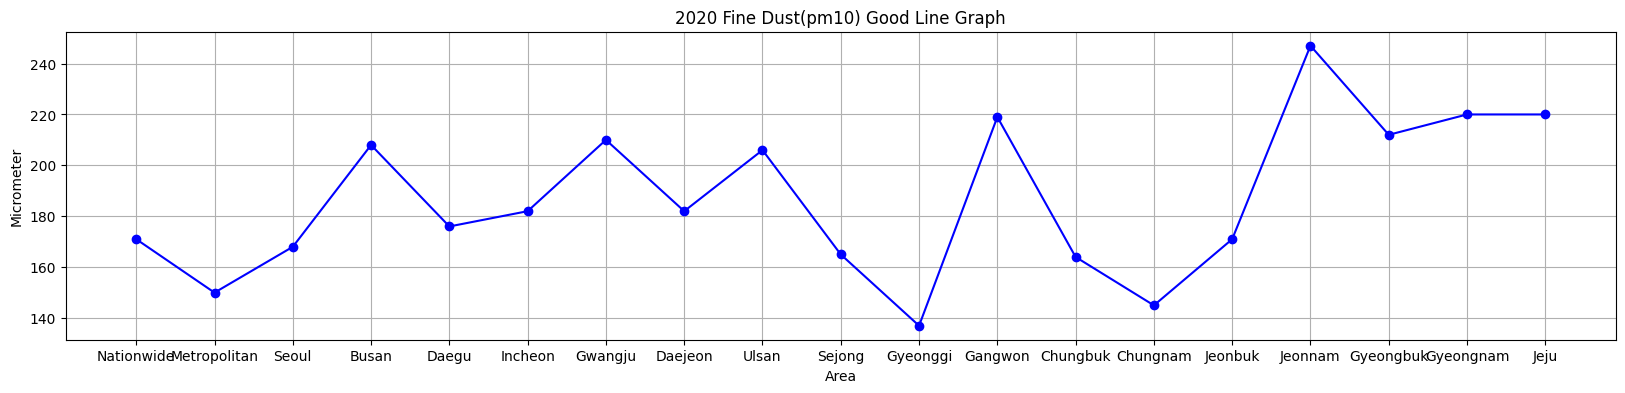

In [6]:
plt.figure(figsize=(20,4))
plt.plot(data2020_good, color='b', marker='o')
plt.xlabel('Area')
plt.ylabel('Micrometer')
plt.title('2020 Fine Dust(pm10) Good Line Graph')
plt.grid()
plt.show()

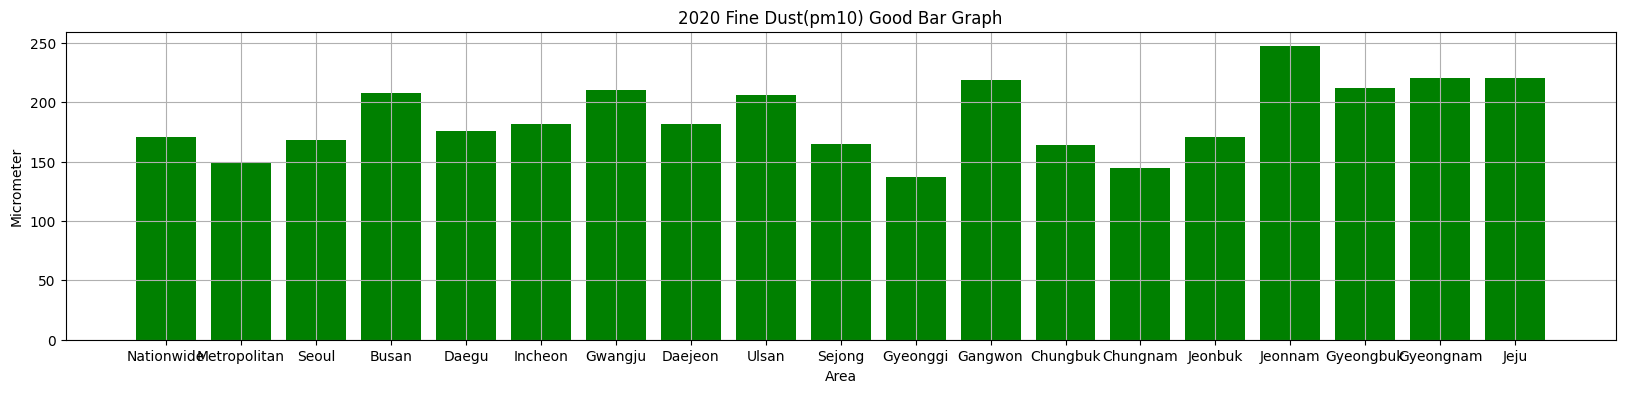

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,4))
plt.bar(data2020_good.index, data2020_good, color='g')
plt.xlabel('Area')
plt.ylabel('Micrometer')
plt.title('2020 Fine Dust(pm10) Good Bar Graph')
plt.grid()
plt.show()

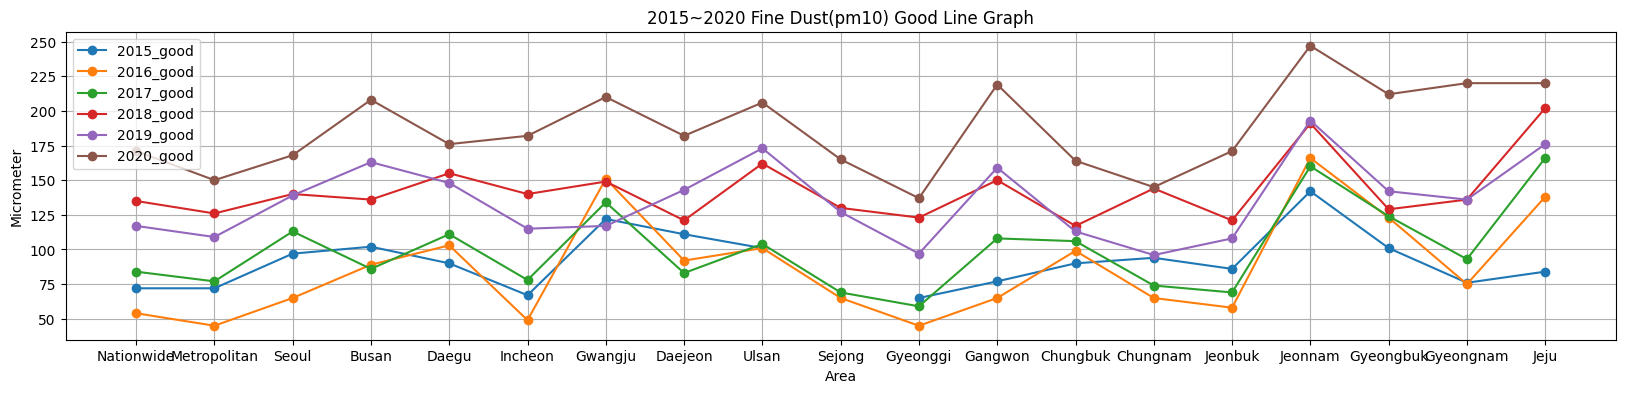

In [8]:
plt.figure(figsize=(20,4))

for year in range(2015, 2021):
  year = str(year)+'_good'
  chartdata = data[year]
  plt.plot(chartdata, marker='o', label=year)

plt.xlabel('Area')
plt.ylabel('Micrometer')
plt.title('2015~2020 Fine Dust(pm10) Good Line Graph')
plt.legend()
plt.grid()
plt.show()

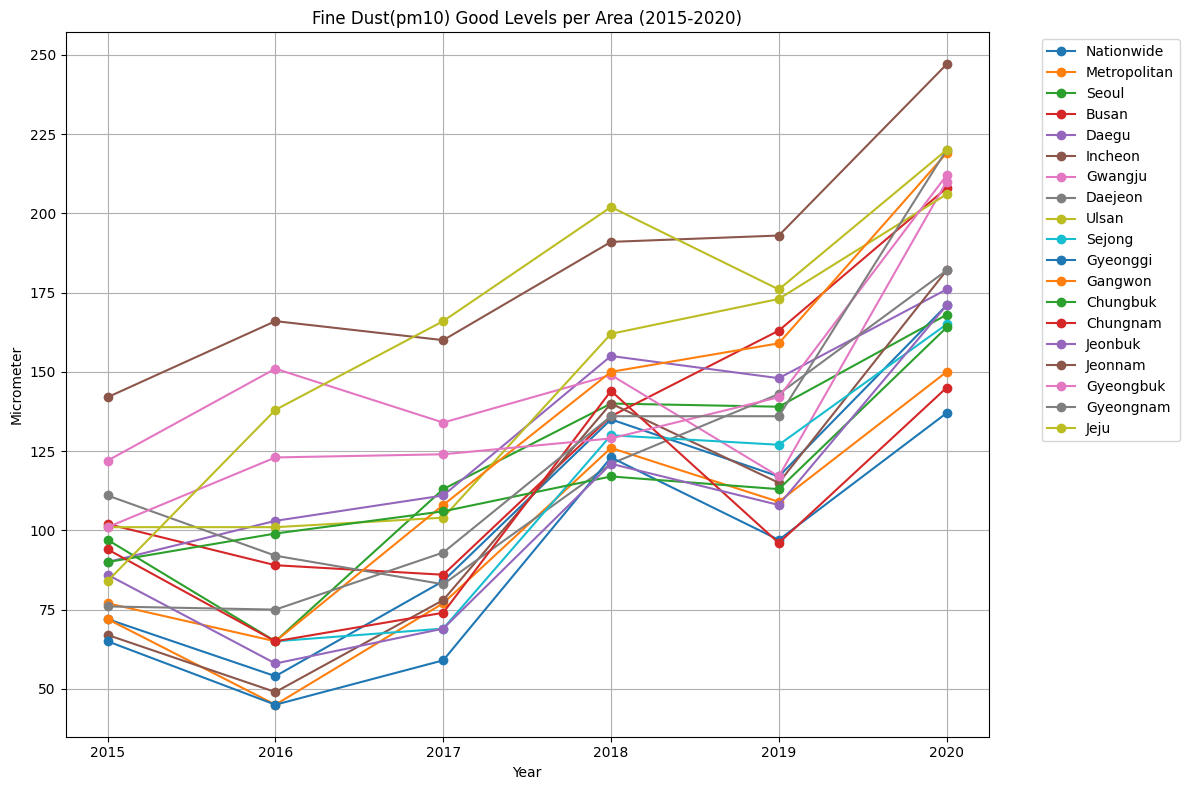

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8)) # Adjust figure size for better readability

years = range(2015, 2021)
year_cols = [str(year) + '_good' for year in years]

# Iterate through each area (row in the DataFrame)
for area_name in data.index:
    # Get the fine dust 'good' values for this area across all years
    area_values = data.loc[area_name, year_cols]
    plt.plot(years, area_values, marker='o', label=area_name)

plt.xlabel('Year')
plt.ylabel('Micrometer')
plt.title('Fine Dust(pm10) Good Levels per Area (2015-2020)')
plt.xticks(list(years)) # Ensure all years are shown as x-ticks
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside to avoid overlap
plt.grid(True)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### 히트맵을 사용하여 연도별 지역 미세먼지 '좋음' 수치 시각화

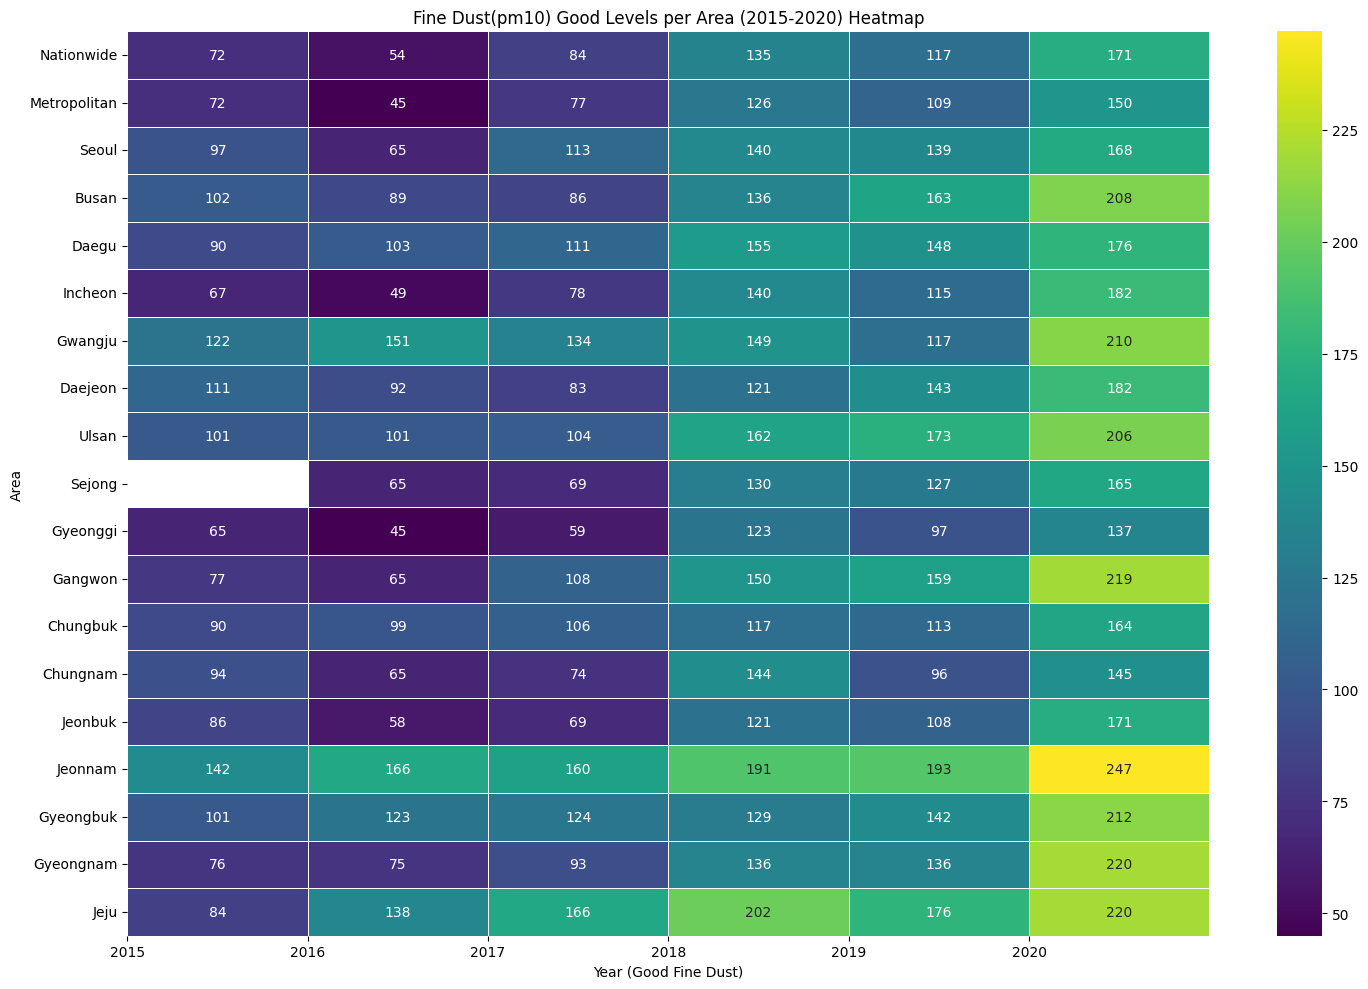

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

years = range(2015, 2021)
year_cols = [str(year) + '_good' for year in years]

# Prepare the data for the heatmap
# The 'data' DataFrame already has areas as index and year_cols as columns
heatmap_data = data[year_cols]

plt.figure(figsize=(15, 10)) # Adjust figure size for better readability
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="viridis", linewidths=.5)

plt.xlabel('Year (Good Fine Dust)')
plt.ylabel('Area')
plt.title('Fine Dust(pm10) Good Levels per Area (2015-2020) Heatmap')
plt.xticks(ticks=range(len(years)), labels=[str(year) for year in years]) # Set x-axis labels to just the years
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

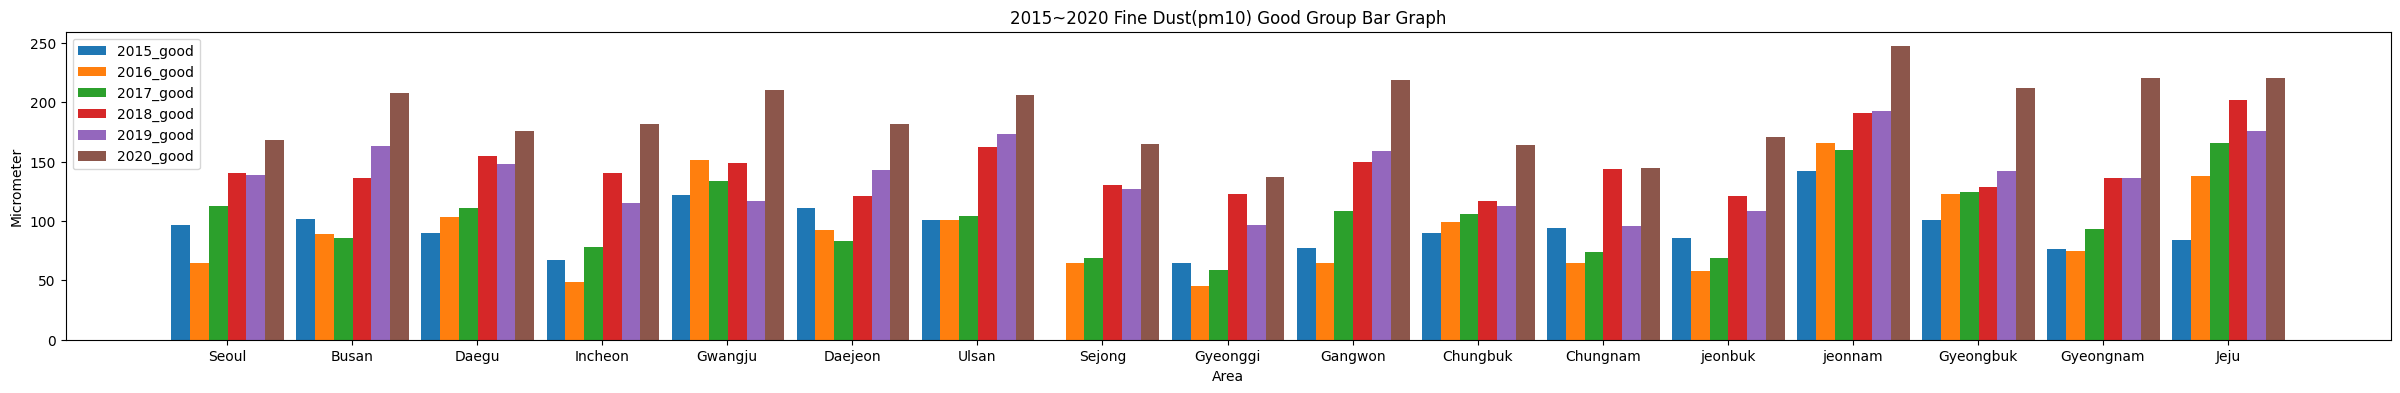

In [11]:
import numpy as np
index = np.arange(17)

plt.figure(figsize=(30,4))

data6 = data.loc['Seoul':'Jeju', '2015_good':'2020_good']
for year in range(2015, 2021):
  year = str(year)+'_good'
  chartdata = data6[year]
  plt.bar(index, chartdata, width=0.15, label=year)
  index = index + 0.15

plt.xlabel('Area')
plt.ylabel('Micrometer')
plt.xticks(index-0.53, ['Seoul', 'Busan', 'Daegu', 'Incheon', 'Gwangju', 'Daejeon', 'Ulsan', 'Sejong', 'Gyeonggi', 'Gangwon','Chungbuk', 'Chungnam', 'jeonbuk','jeonnam', 'Gyeongbuk','Gyeongnam','Jeju'])
plt.title('2015~2020 Fine Dust(pm10) Good Group Bar Graph')
plt.legend()
plt.show()

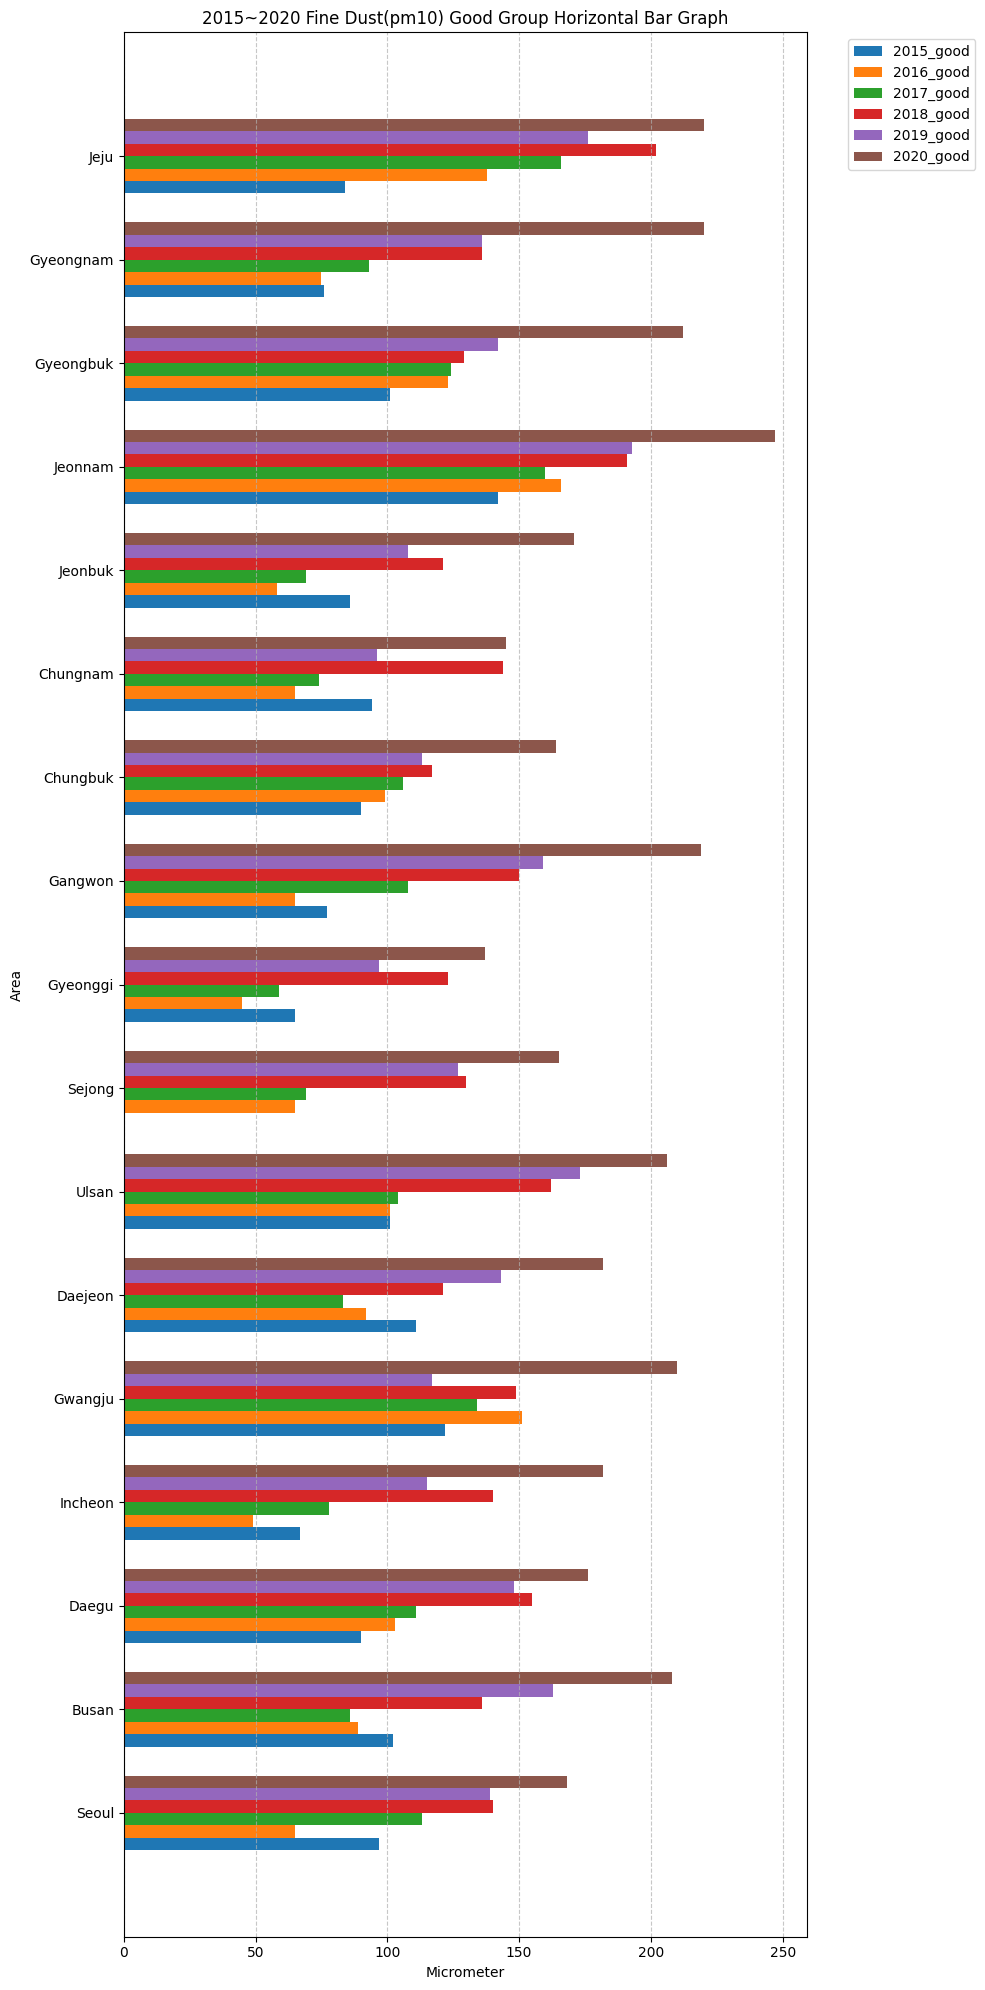

In [12]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 20)) # Adjust figure size for horizontal display

# data6 is already defined in the previous cell's execution, reusing it.
# data6 = data.loc['Seoul':'Jeju', '2015_good':'2020_good']

# Number of areas (rows in data6)
num_areas = len(data6.index)
# Number of years
years_to_plot = range(2015, 2021)
num_years = len(years_to_plot)

# Base index for each area (y-position for the group of bars)
base_indices = np.arange(num_areas)

bar_height = 0.12 # Height of individual bars

# Calculate the starting y-position for the first bar in each group
# This centers the group of bars around the `base_indices`
y_offset_start = bar_height * (0.5 - num_years / 2)

for i, year in enumerate(years_to_plot):
    year_col = str(year) + '_good'
    chartdata = data6[year_col]
    # Calculate the y-position for the current year's bars
    y_positions = base_indices + y_offset_start + (i * bar_height)
    plt.barh(y_positions, chartdata, height=bar_height, label=year_col)

plt.xlabel('Micrometer') # X-axis is now Micrometer (bar length)
plt.ylabel('Area')       # Y-axis is now Area
plt.yticks(base_indices, data6.index) # Set y-axis ticks to area names, centered on the group
plt.title('2015~2020 Fine Dust(pm10) Good Group Horizontal Bar Graph')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside
plt.grid(axis='x', linestyle='--', alpha=0.7) # Grid on x-axis
plt.tight_layout()
plt.show()

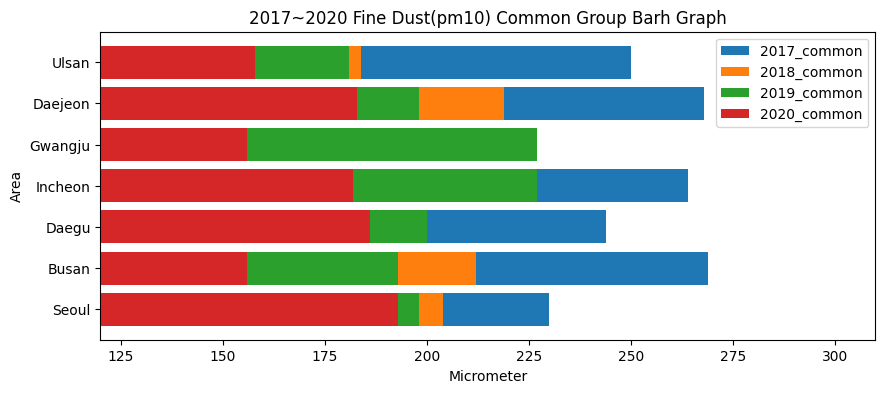

In [13]:
import numpy as np
index = np.arange(7)

plt.figure(figsize=(10,4))

data6 = data.loc['Seoul':'Ulsan', '2017_common':'2020_common']
for year in range(2017, 2021):
  year = str(year)+'_common'
  chartdata = data6[year]
  plt.barh(index, chartdata, label=year)

plt.xlim(120,310)
plt.ylabel('Area')
plt.xlabel('Micrometer')
plt.yticks(index, ['Seoul', 'Busan', 'Daegu', 'Incheon', 'Gwangju', 'Daejeon', 'Ulsan'])
plt.title('2017~2020 Fine Dust(pm10) Common Group Barh Graph')
plt.legend()
plt.show()

1. 서울의 공기질은 그래서 좋아졌을까요? 나빠졌을까요?
===> 한눈에 알아볼 수 있는 가장 좋은 그래프를 그리세요.

2. 한국에서 미세먼지가 가장 심한 도시 (very_bad) 는 어디일까요? 6년치 모두 비교하기 좋은 그래프

3. 2018년도에는 어떤 일이 있었을까요?

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv('/content/drive/MyDrive/MyLecture/2026/데이터시각화/04_data2.csv')
data

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


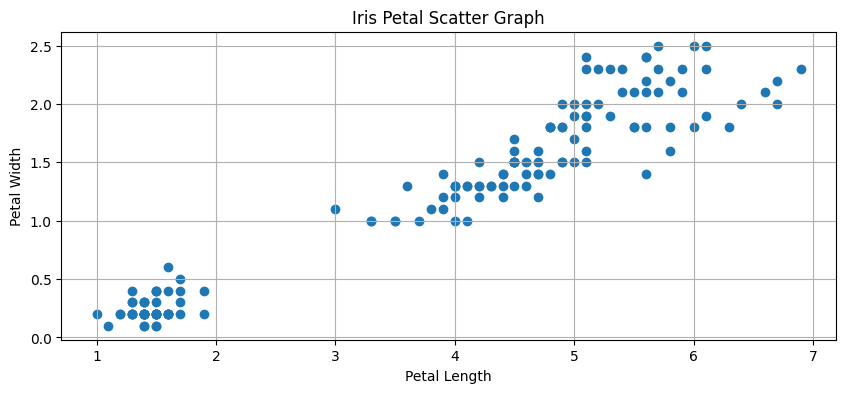

In [15]:
PetalLength = data['PetalLength']
PetalWidth = data['PetalWidth']

plt.figure(figsize=(10,4))
plt.scatter(PetalLength, PetalWidth)

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Iris Petal Scatter Graph')
plt.grid()
plt.show()

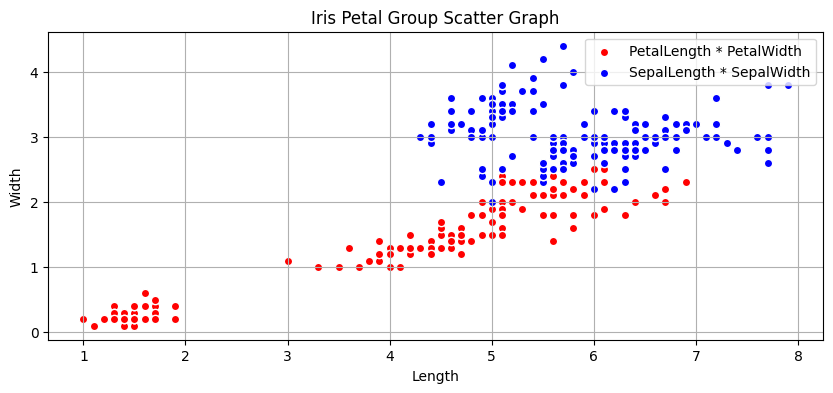

In [16]:
PetalLength = data['PetalLength']
PetalWidth = data['PetalWidth']

SepalLength = data['SepalLength']
SepalWidth = data['SepalWidth']

plt.figure(figsize=(10,4))
plt.scatter(PetalLength, PetalWidth, color='r', edgecolor='w', label='PetalLength * PetalWidth')
plt.scatter(SepalLength, SepalWidth, color='b', edgecolor='w', label='SepalLength * SepalWidth')

plt.xlabel('Length')
plt.ylabel('Width')
plt.title('Iris Petal Group Scatter Graph')
plt.legend()
plt.grid()
plt.show()

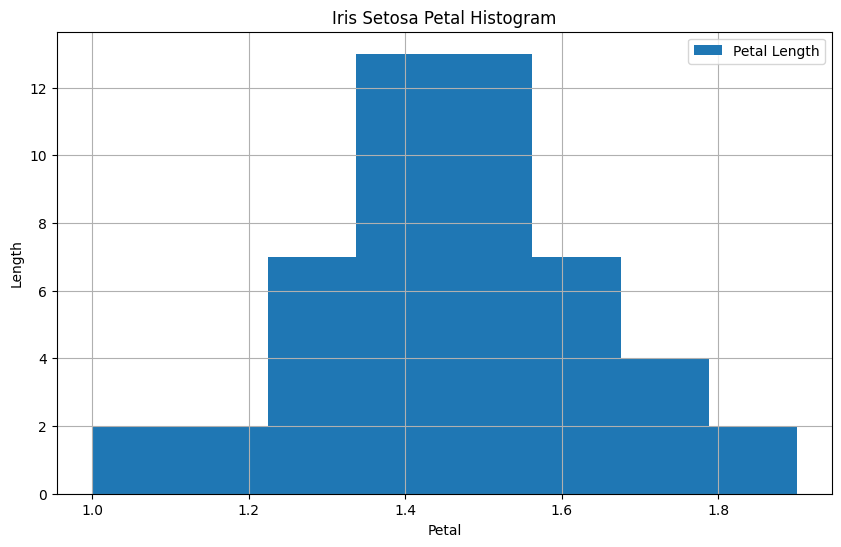

In [17]:
setosa = data.loc[data.Species=='setosa',['Species','PetalLength']]

plt.figure(figsize=(10,6))
plt.hist(setosa['PetalLength'], bins=8, label='Petal Length')

plt.xlabel('Petal')
plt.ylabel('Length')
plt.title('Iris Setosa Petal Histogram')
plt.legend()
plt.grid()
plt.show()

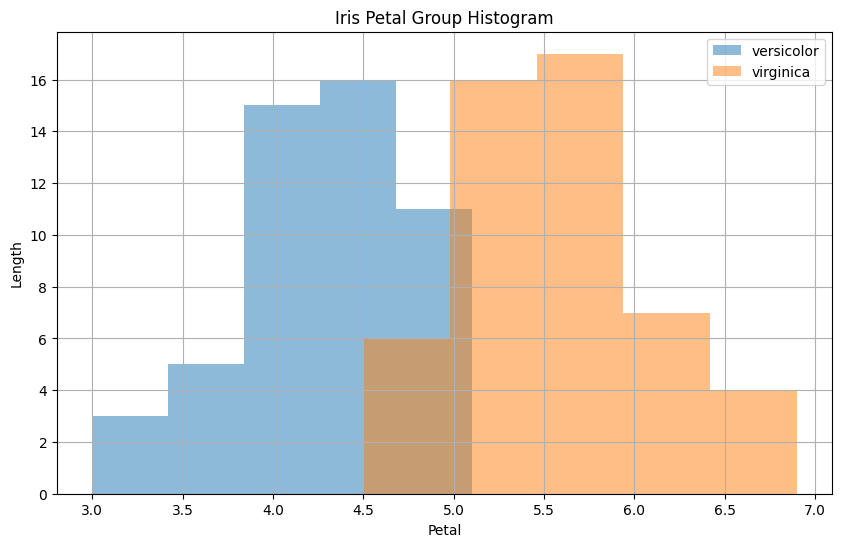

In [18]:
versicolor_PetalLength = data.loc[data.Species=='versicolor',['Species','PetalLength']]
virginica_PetalLength = data.loc[data.Species=='virginica',['Species','PetalLength']]

plt.figure(figsize=(10,6))
plt.hist(versicolor_PetalLength['PetalLength'], bins=5, alpha=0.5, label='versicolor')
plt.hist(virginica_PetalLength['PetalLength'], bins=5, alpha=0.5, label='virginica')

plt.xlabel('Petal')
plt.ylabel('Length')
plt.title('Iris Petal Group Histogram')
plt.legend()
plt.grid()
plt.show()

/tmp/ipykernel_594/2523947939.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([SepalLength, SepalWidth], labels=['Sepal Length','Sepal Width'])


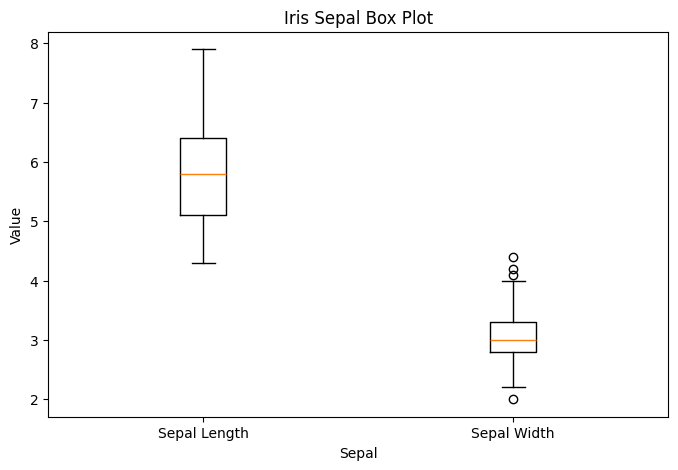

In [19]:
SepalLength = data['SepalLength']
SepalWidth = data['SepalWidth']

plt.figure(figsize=(8,5))
plt.boxplot([SepalLength, SepalWidth], labels=['Sepal Length','Sepal Width'])

plt.xlabel('Sepal')
plt.ylabel('Value')
plt.title('Iris Sepal Box Plot')
plt.show()

/tmp/ipykernel_594/496064830.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([SepalLength, SepalWidth], labels=['Sepal Length','Sepal Width'], vert=False)


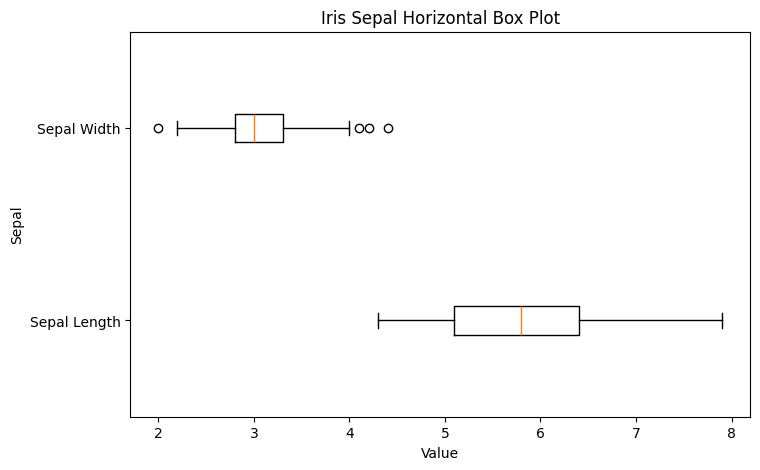

In [20]:
plt.figure(figsize=(8,5))
plt.boxplot([SepalLength, SepalWidth], labels=['Sepal Length','Sepal Width'], vert=False)

plt.ylabel('Sepal')
plt.xlabel('Value')
plt.title('Iris Sepal Horizontal Box Plot')
plt.show()